In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from src.processing import find_pareto_front, history_to_dataframe
from src.visualization import (display_pareto_front, display_two_pareto_fronts, display_pareto_fronts3, 
                               display_fitness_landscape_with_2pareto, gerar_gif_evolucao_nsga2, display_evolution_of_genotypes, display_fitness_landscape_with_paretos)
from src.metrics import calculate_gamma_convergence_metric, print_gamma_metric

/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Parâmetros NSGA-II
config = {
    # definindo o algoritmo
    'population_size': 100,
    'n_generations': 100,
    'k_tournament': 2,
    'crossover_prob': 0.9,
    'crossover_eta': 15,
    'mutation_prob': 1/6,  # 1/n_var
    'mutation_eta': 20,
    'seed': 42,
    'track_progress': True,

    # definindo o problema
    'n_objetivos': 2,
    'fitness_cols': ["fitness1", "fitness2"],
    'maximize': True,
    'n_restricoes': 0,

    # definindo o genótipo
    'tamanho_genotipo': 6,
    'limite_inferior': np.array([0, 0, 0, 0, 0, 0]),
    'limite_superior': np.array([9, 9, 9, 9, 9, 9]),
    'tipo_variavel_genotipo': int
}

In [3]:
df1 = pd.read_parquet('data/df_surrogate1.parquet')
df2 = pd.read_parquet('data/df_surrogate2.parquet')

print(df1.shape)
print(df2.shape)
display(df2.head())

(1000000, 45)
(1000000, 49)


,registro,fitness1_eq0,fitness1_eq1,fitness1_eq2,fitness1_eq3,fitness1_eq4,fitness1_eq5,fitness1_eq6,fitness1_eq7,fitness1_eq8,...,erro_abs1_c3,fitness2_c1,fitness2_c2,fitness2_c3,erro2_c1,erro_abs2_c1,erro2_c2,erro_abs2_c2,erro2_c3,erro_abs2_c3
0,0,0.000000e+00,10.0,7.0,4.0,5.0,5.0,0.0000,3.000000,2.000000,...,3.872849,11.954354,11.351299,11.587111,-2.467936,2.467936,-1.864882,1.864882,-2.100693,2.100693
1,1,5.714286e-12,10.0,7.0,4.0,5.0,5.0,0.0004,3.000000,1.999998,...,3.874625,11.846353,11.397690,11.587111,-2.361397,2.361397,-1.912734,1.912734,-2.102156,2.102156
2,2,2.285714e-11,10.0,7.0,4.0,5.0,5.0,0.0008,2.999999,1.999994,...,3.083213,11.846353,11.397690,11.184368,-2.362858,2.362858,-1.914195,1.914195,-1.700874,1.700874
3,3,5.142857e-11,10.0,7.0,4.0,5.0,5.0,0.0012,2.999998,1.999986,...,3.160968,11.846353,11.397690,11.170272,-2.364318,2.364318,-1.915655,1.915655,-1.688238,1.688238
4,4,9.142857e-11,10.0,7.0,4.0,5.0,5.0,0.0016,2.999996,1.999975,...,3.162737,11.846353,11.397690,11.170272,-2.365776,2.365776,-1.917113,1.917113,-1.689696,1.689696


In [4]:
df_mcmc1 = pd.read_parquet('data/df_mcmc1.parquet').rename(columns={'index_linha': 'id_simulacao'})
df_mcmc2 = pd.read_parquet('data/df_mcmc2.parquet').rename(columns={'index_linha': 'id_simulacao'})

df_mcmc1.sort_values(['regiao', 'id_simulacao'], inplace=True)
df_mcmc2.sort_values(['regiao', 'id_simulacao'], inplace=True)

config['n_simulations'] = df_mcmc2['id_simulacao'].max() + 1
print('n_simulations: ', config['n_simulations'])

print(df_mcmc1.shape)
print(df_mcmc2.shape)
df_mcmc2

n_simulations:  30
(300, 4)
(300, 4)


,id_simulacao,regiao,erro1_c1,erro2_c1
0,0,1,3.252180,-2.792795
1,1,1,4.364665,-3.421710
2,2,1,4.286103,-1.688528
3,3,1,4.319016,-4.042480
4,4,1,4.403225,-2.413870
...,...,...,...,...
295,25,9,-1.901665,1.848962
296,26,9,-2.296525,1.646416
297,27,9,-3.004068,1.397452
298,28,9,-2.932516,0.618620


# Visualizando algoritmo

In [5]:
cols_landscape = ['registro', 'id_simulacao', 'fitness1', 'fitness2']
cols_df = ['registro', 'regiao', 'fitness1_c1', 'fitness2_c1']

df_landscape1 = df1[cols_df].merge(df_mcmc1, on='regiao', how='left')
print(df_landscape1.shape)

df_landscape1['fitness1'] = round(df_landscape1['fitness1_c1'] + df_landscape1['erro1_c1'], 3)
df_landscape1['fitness2'] = round(df_landscape1['fitness2_c1'] + df_landscape1['erro2_c1'], 3)
df_landscape1 = df_landscape1[cols_landscape]
df_landscape1 = (df_landscape1
                 .groupby('registro', as_index=False)
                 .agg({
                     'fitness1': list,
                     'fitness2': list
                 }))

print(df_landscape1.shape)
df_landscape1

(30000000, 7)
(1000000, 3)


,registro,fitness1,fitness2
0,0,"[2.655, 4.271, 4.466, 3.325, 4.284, 4.284, 3.7...","[3.578, 4.04, 4.222, 3.456, 4.42, 3.971, 3.741..."
1,1,"[2.655, 4.271, 4.466, 3.325, 4.284, 4.284, 3.7...","[3.578, 4.04, 4.222, 3.456, 4.42, 3.971, 3.741..."
2,2,"[2.655, 4.271, 4.466, 3.325, 4.284, 4.284, 3.7...","[3.578, 4.04, 4.222, 3.456, 4.42, 3.971, 3.741..."
3,3,"[2.655, 4.271, 4.466, 3.325, 4.284, 4.284, 3.7...","[3.578, 4.04, 4.222, 3.456, 4.42, 3.971, 3.741..."
4,4,"[2.655, 4.271, 4.466, 3.325, 4.284, 4.284, 3.7...","[3.578, 4.04, 4.222, 3.456, 4.42, 3.971, 3.741..."
...,...,...,...
999995,999995,"[3.898, 3.949, 4.771, 3.951, 4.685, 4.772, 3.2...","[1.608, 1.454, 2.224, 1.854, 1.693, 1.426, 1.1..."
999996,999996,"[3.898, 3.949, 4.771, 3.951, 4.685, 4.772, 3.2...","[1.608, 1.454, 2.224, 1.854, 1.693, 1.426, 1.1..."
999997,999997,"[3.898, 3.949, 4.771, 3.951, 4.685, 4.772, 3.2...","[1.608, 1.454, 2.224, 1.854, 1.693, 1.426, 1.1..."
999998,999998,"[3.898, 3.949, 4.771, 3.951, 4.685, 4.772, 3.2...","[1.608, 1.454, 2.224, 1.854, 1.693, 1.426, 1.1..."


In [6]:
from src.ua_sa_nsga2.individual     import Individual
from src.ua_sa_nsga2.inicialization import initialize_population
from src.ua_sa_nsga2.evaluation     import evaluate_population, genotype_to_registro
from src.ua_sa_nsga2.offspring      import create_offspring_population
from src.ua_sa_nsga2.selection      import environmental_selection

df_landscape = df_landscape1.copy()

######### 1. População Inicial (initial population)
# Define random seed    
np.random.seed(42)

# Inicializando população de soluções    
population, _ = initialize_population(config)

# Avalia fitness da população inicial
evaluate_population(population, df_landscape, config['fitness_cols'], config['maximize'])


############# Loop principal das gerações
for generation in [0]:#tqdm(range(config['n_generations'])):

    ######### 2. População Descendente (offspring population)
    # Criar população descendente Qt
    offspring = create_offspring_population(population, config)

    # Avalia fitness da população descendente
    evaluate_population(offspring, df_landscape, config['fitness_cols'], config['maximize'])


    ######### 3. Seleção Geracional (generational selection)
    # Combinar Pt e Qt para formar Rt
    combined_population = population + offspring

    # Seleção geracional: selecionar N melhores para formar P(t+1)
    population = environmental_selection(combined_population, config)


population

[Individual([9, 0, 5, 0, 7, 8], fitness=[[6.122, 6.173, 6.995, 6.175, 6.909, 6.995, 5.426, 6.672, 5.855, 6.24, 6.449, 7.0, 4.831, 7.027, 7.071, 4.496, 7.149, 6.142, 6.764, 4.353, 5.823, 6.539, 6.217, 6.255, 6.365, 6.466, 6.384, 4.056, 6.625, 4.096], [2.998, 2.844, 3.614, 3.244, 3.083, 2.816, 2.565, 2.868, 3.043, 2.683, 3.483, 2.522, 2.522, 3.031, 3.473, 2.411, 3.511, 2.823, 2.675, 2.436, 2.786, 3.197, 3.271, 2.681, 3.064, 2.86, 3.503, 2.326, 3.389, 2.682]], rank=1.73333, ua_rank=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 5, 1, 1, 1, 8, 1, 1, 1, 1, 1, 1, 1, 5, 1, 5], rank_std=0.61111),
 Individual([3, 3, 2, 9, 7, 0], fitness=[[4.582, 4.613, 4.648, 4.37, 4.56, 4.564, 4.383, 4.611, 4.448, 4.373, 3.743, 3.393, 4.554, 4.319, 4.521, 4.623, 4.62, 4.607, 4.343, 4.56, 4.198, 4.248, 4.431, 4.573, 4.191, 4.644, 4.642, 3.916, 4.587, 4.452], [4.244, 4.247, 4.295, 4.086, 4.091, 4.249, 3.593, 4.094, 4.301, 4.198, 3.628, 3.595, 4.22, 3.841, 3.852, 3.849, 3.473, 4.216, 3.856, 4.152, 3.657, 3.269, 4.

# Problema 1

In [7]:
from src.nsgaII import run_my_nsga2
from src.ua_sa_nsgaII import run_my_uasa_nsga2

In [8]:
cols_landscape = ['registro', 'id_simulacao', 'fitness1', 'fitness2']
cols_df = ['registro', 'regiao', 'fitness1_c1', 'fitness2_c1']

df_landscape1 = df1[cols_df].merge(df_mcmc1, on='regiao', how='left')
print(df_landscape1.shape)

df_landscape1['fitness1'] = round(df_landscape1['fitness1_c1'] + df_landscape1['erro1_c1'], 3)
df_landscape1['fitness2'] = round(df_landscape1['fitness2_c1'] + df_landscape1['erro2_c1'], 3)
df_landscape1 = df_landscape1[cols_landscape]
df_landscape1 = (df_landscape1
                 .groupby('registro', as_index=False)
                 .agg({
                     'fitness1': list,
                     'fitness2': list
                 }))

print(df_landscape1.shape)
df_landscape1

(30000000, 7)
(1000000, 3)


,registro,fitness1,fitness2
0,0,"[2.655, 4.271, 4.466, 3.325, 4.284, 4.284, 3.7...","[3.578, 4.04, 4.222, 3.456, 4.42, 3.971, 3.741..."
1,1,"[2.655, 4.271, 4.466, 3.325, 4.284, 4.284, 3.7...","[3.578, 4.04, 4.222, 3.456, 4.42, 3.971, 3.741..."
2,2,"[2.655, 4.271, 4.466, 3.325, 4.284, 4.284, 3.7...","[3.578, 4.04, 4.222, 3.456, 4.42, 3.971, 3.741..."
3,3,"[2.655, 4.271, 4.466, 3.325, 4.284, 4.284, 3.7...","[3.578, 4.04, 4.222, 3.456, 4.42, 3.971, 3.741..."
4,4,"[2.655, 4.271, 4.466, 3.325, 4.284, 4.284, 3.7...","[3.578, 4.04, 4.222, 3.456, 4.42, 3.971, 3.741..."
...,...,...,...
999995,999995,"[3.898, 3.949, 4.771, 3.951, 4.685, 4.772, 3.2...","[1.608, 1.454, 2.224, 1.854, 1.693, 1.426, 1.1..."
999996,999996,"[3.898, 3.949, 4.771, 3.951, 4.685, 4.772, 3.2...","[1.608, 1.454, 2.224, 1.854, 1.693, 1.426, 1.1..."
999997,999997,"[3.898, 3.949, 4.771, 3.951, 4.685, 4.772, 3.2...","[1.608, 1.454, 2.224, 1.854, 1.693, 1.426, 1.1..."
999998,999998,"[3.898, 3.949, 4.771, 3.951, 4.685, 4.772, 3.2...","[1.608, 1.454, 2.224, 1.854, 1.693, 1.426, 1.1..."


In [9]:
# experimento
df = df1.copy()
df_predicted = df1.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)

100%|██████████| 100/100 [00:07<00:00, 14.19it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 48


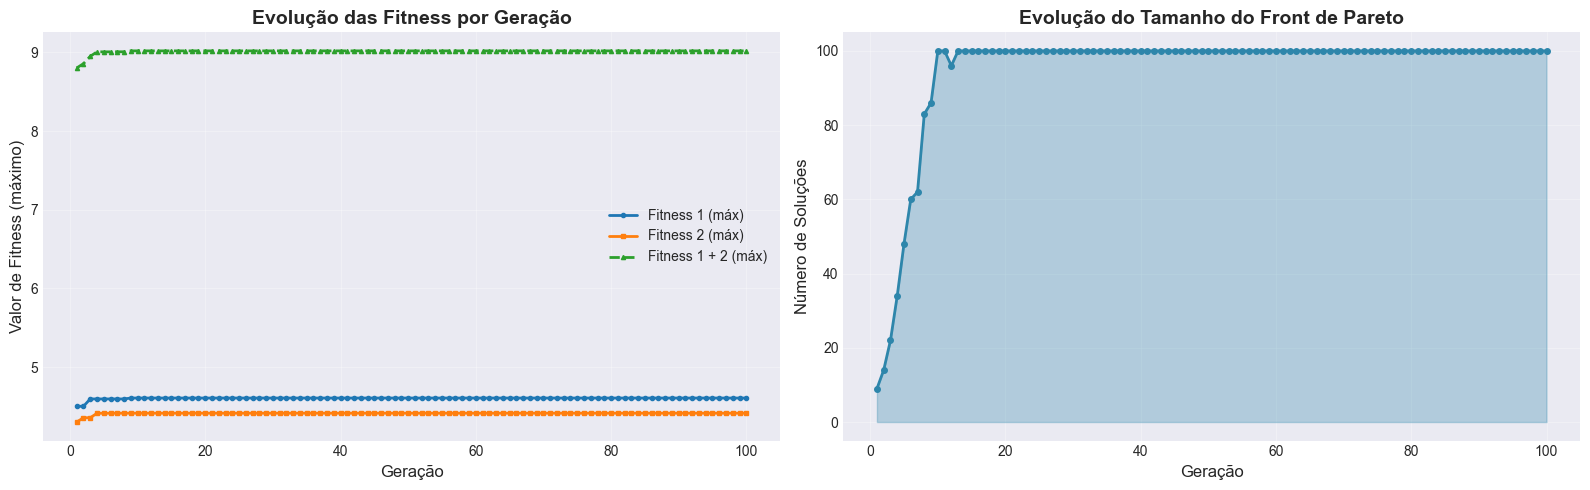


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [00:16<00:00,  5.90it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 7


In [10]:
df_pareto_my, _, _, _  = run_my_nsga2(config, df_predicted)
df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape1, save_history=True)

### Problema 1. Landscape Real

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 10,344 pontos.
Isso representa 1.0344% do espaço de busca.


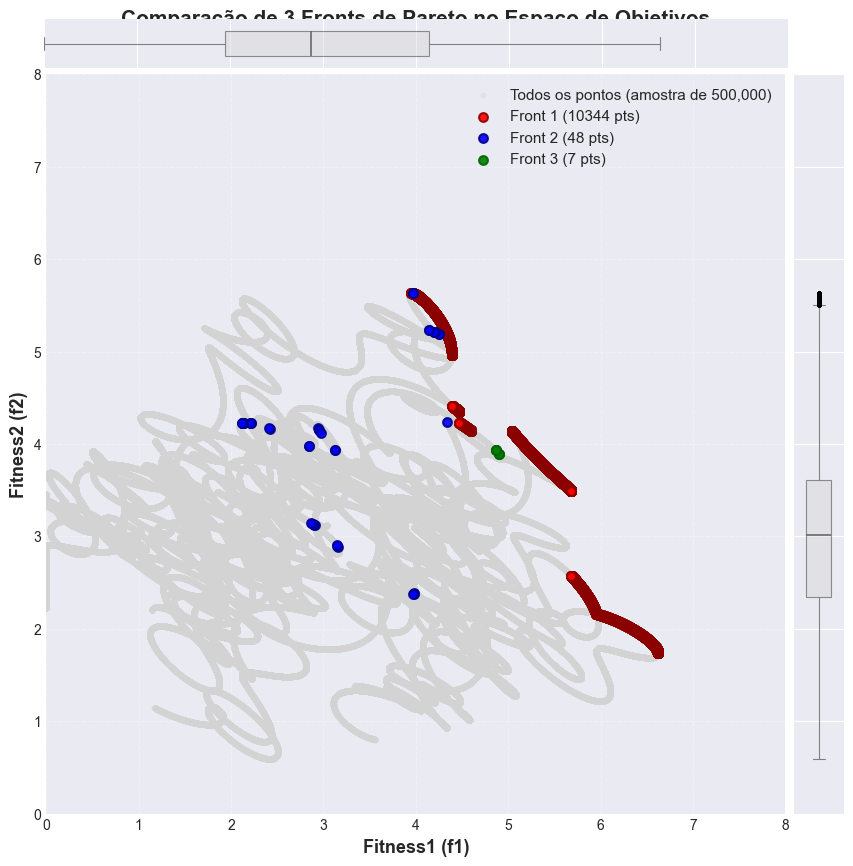

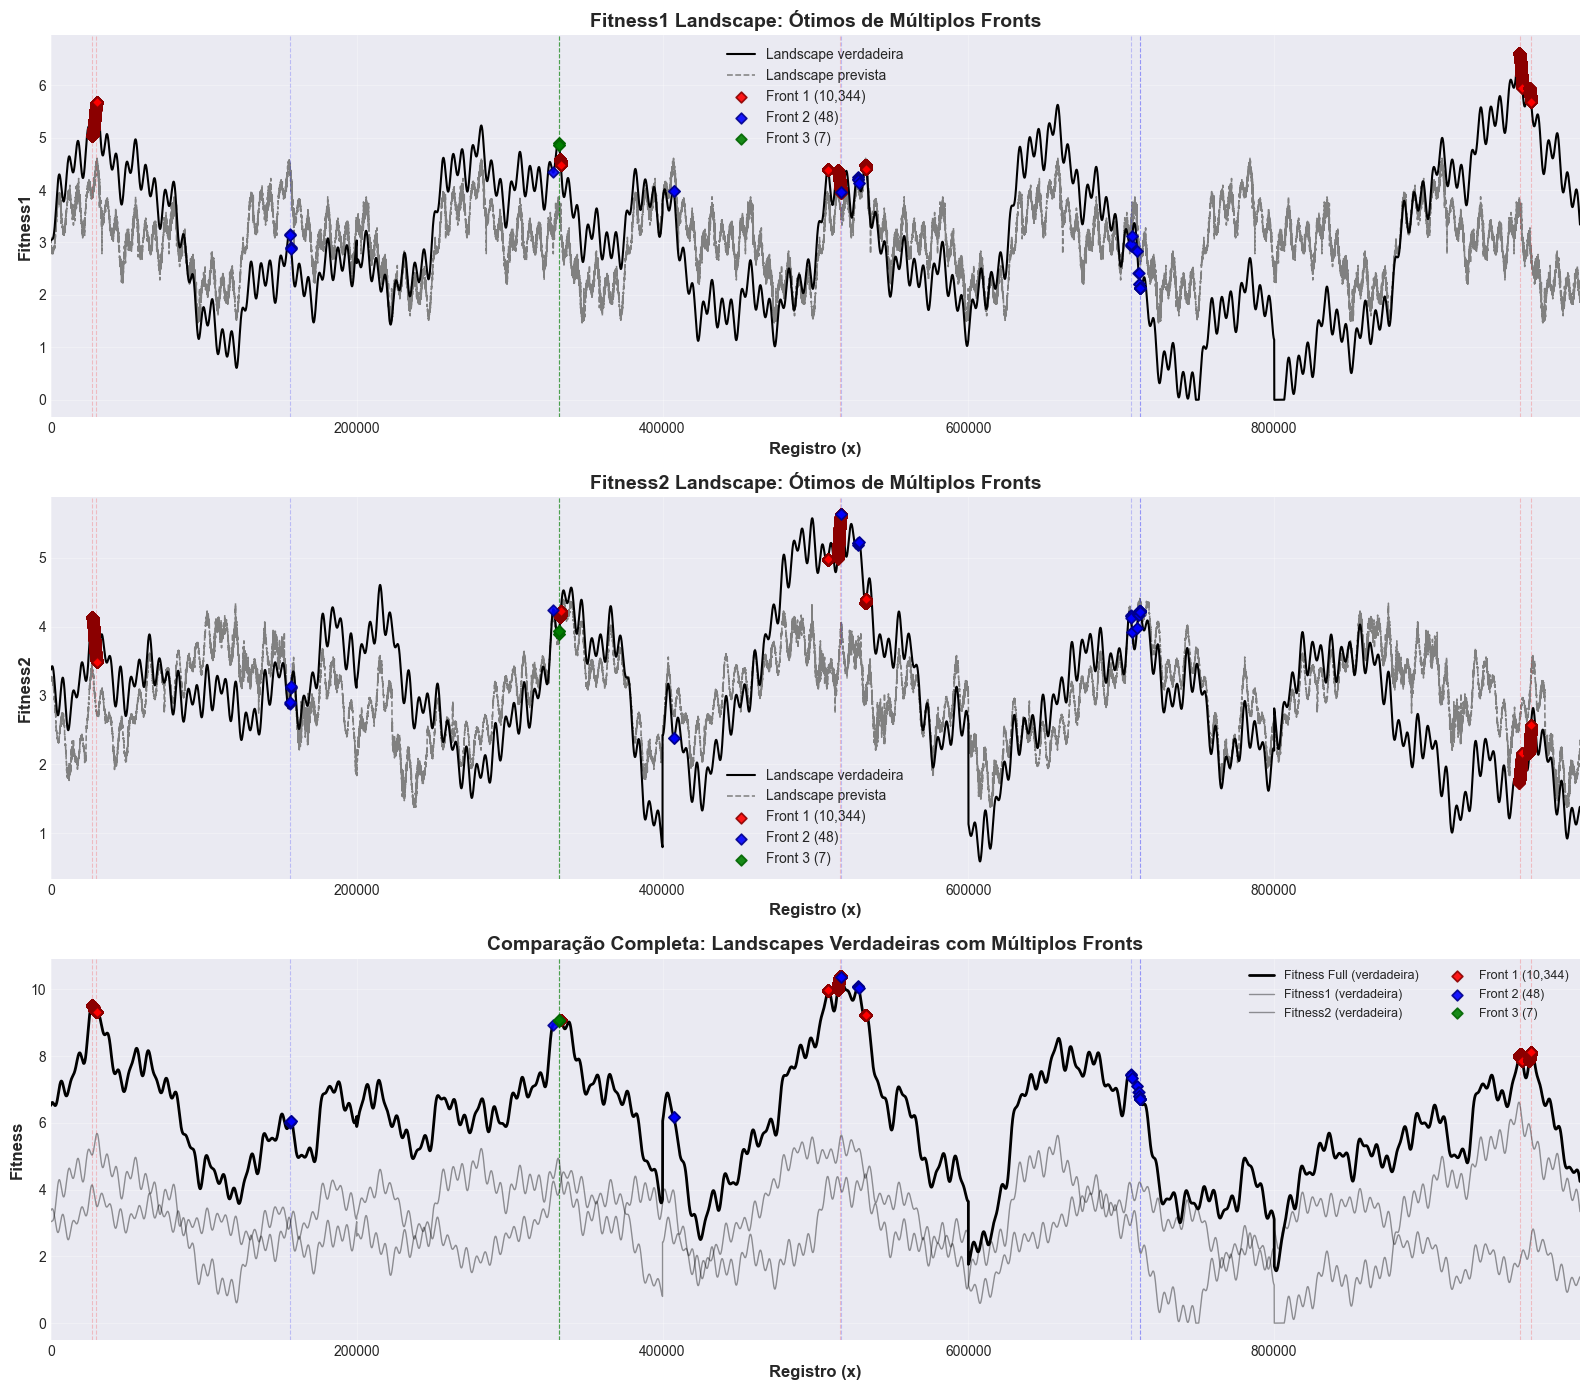

===================== gamma ua-sa-nsga2 =====================
🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.265664
   • Desvio Padrão:            0.002294
===================== gamma nsga2 =====================
🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        1.536253
   • Desvio Padrão:            0.832800


In [11]:
df_pareto_real = find_pareto_front(df)

df_pareto_real = df[df.registro.isin(df_pareto_real.registro.unique())]
df_pareto_my = df[df.registro.isin(df_pareto_my.registro.unique())]
df_pareto_ua_sa = df[df.registro.isin(df_pareto_ua_sa.registro.unique())]

# convergencia entre resultados
display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa])
display_fitness_landscape_with_paretos(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa])#, n_regioes=10)

print('===================== gamma ua-sa-nsga2 =====================')
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

print('===================== gamma nsga2 =====================')
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

In [12]:
# Gerar GIF com a evolução das populações
caminho_gif = gerar_gif_evolucao_nsga2(
    df_landscape=df,  # Mesmo dataframe usado acima
    history=history,
    nome_arquivo='evolucao_ua_sa_nsga2_df1.gif',
    fps=5,  # Ajuste a velocidade conforme preferir
    output_dir='data'
)

print(f"GIF salvo em: {caminho_gif}")

Iniciando a geração de 101 frames...
Processado 10/101 frames...
Processado 20/101 frames...
Processado 30/101 frames...
Processado 40/101 frames...
Processado 50/101 frames...
Processado 60/101 frames...
Processado 70/101 frames...
Processado 80/101 frames...
Processado 90/101 frames...
Processado 100/101 frames...
Salvando arquivo 'evolucao_ua_sa_nsga2_df1.gif' no diretório 'data'...

✅ Sucesso! GIF gerado em:
/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/data/evolucao_ua_sa_nsga2_df1.gif
GIF salvo em: /Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/data/evolucao_ua_sa_nsga2_df1.gif


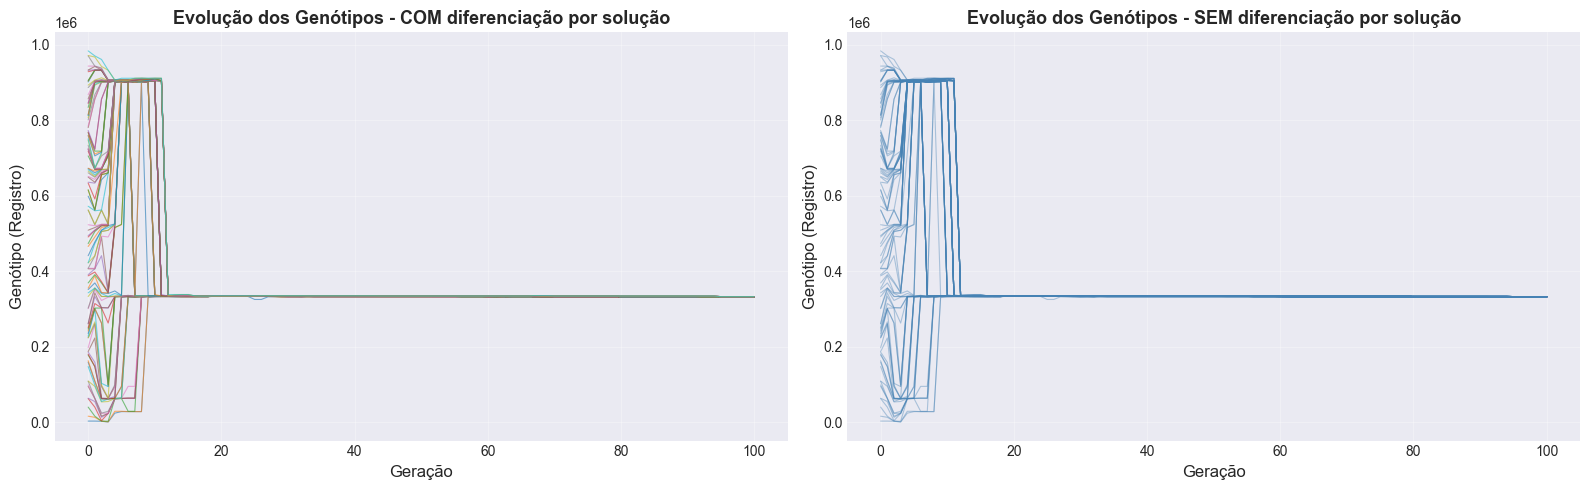


📊 Estatísticas do histórico:
   • Total de registros: 10,100
   • Gerações: 101
   • Soluções por geração: 100
   • Genótipos únicos visitados: 418


In [13]:
df_history = history_to_dataframe(history).drop(columns=['id_solucao'])
df_history = df_history.sort_values(by=['geracao','genotipo'])
df_history['id_solucao'] = df_history.groupby(['geracao']).cumcount() + 1
display_evolution_of_genotypes(df_history)

### Problema 1. Landscape Previsto

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 691 pontos.
Isso representa 0.0691% do espaço de busca.


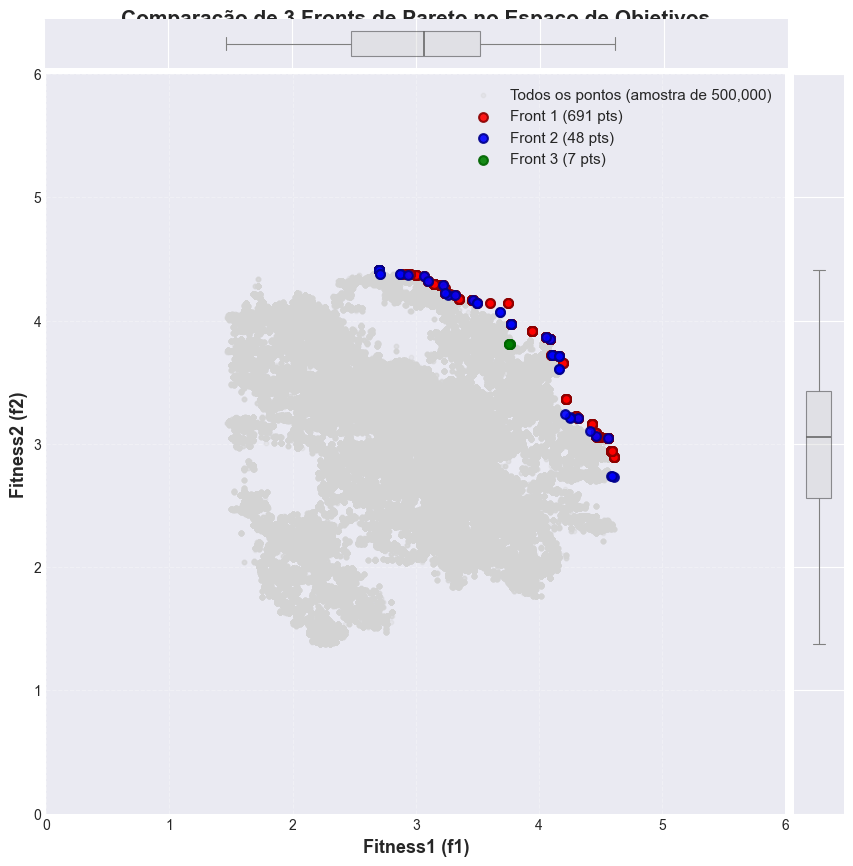

===================== gamma ua-sa-nsga2 =====================
🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.167495
   • Desvio Padrão:            0.002321
===================== gamma nsga2 =====================
🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.023819
   • Desvio Padrão:            0.043118


In [14]:
df_pareto_real = find_pareto_front(df_predicted)

df_pareto_real = df_predicted[df_predicted.registro.isin(df_pareto_real.registro.unique())]
df_pareto_my = df_predicted[df_predicted.registro.isin(df_pareto_my.registro.unique())]
df_pareto_ua_sa = df_predicted[df_predicted.registro.isin(df_pareto_ua_sa.registro.unique())]

# convergencia entre resultados
display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_ua_sa])

print('===================== gamma ua-sa-nsga2 =====================')
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

print('===================== gamma nsga2 =====================')
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

# Problema 2

In [15]:
cols_landscape = ['registro', 'id_simulacao', 'fitness1', 'fitness2']
cols_df = ['registro', 'regiao', 'fitness1_c1', 'fitness2_c1']

df_landscape2 = df2[cols_df].merge(df_mcmc2, on='regiao', how='left')
df_landscape2['fitness1'] = round(df_landscape2['fitness1_c1'] + df_landscape2['erro1_c1'], 3)
df_landscape2['fitness2'] = round(df_landscape2['fitness2_c1'] + df_landscape2['erro2_c1'], 3)
df_landscape2 = df_landscape2[cols_landscape]
df_landscape2 = (df_landscape2
                 .groupby('registro', as_index=False)
                 .agg({
                     'fitness1': list,
                     'fitness2': list
                 }))

df_landscape2

,registro,fitness1,fitness2
0,0,"[15.385, 16.497, 16.419, 16.452, 16.536, 16.53...","[9.162, 8.533, 10.266, 7.912, 9.54, 9.357, 9.0..."
1,1,"[15.5, 16.612, 16.534, 16.567, 16.651, 16.651,...","[9.054, 8.425, 10.158, 7.804, 9.432, 9.249, 8...."
2,2,"[15.5, 16.612, 16.534, 16.567, 16.651, 16.651,...","[9.054, 8.425, 10.158, 7.804, 9.432, 9.249, 8...."
3,3,"[15.5, 16.612, 16.534, 16.567, 16.651, 16.651,...","[9.054, 8.425, 10.158, 7.804, 9.432, 9.249, 8...."
4,4,"[15.5, 16.612, 16.534, 16.567, 16.651, 16.651,...","[9.054, 8.425, 10.158, 7.804, 9.432, 9.249, 8...."
...,...,...,...
999995,999995,"[7.878, 7.787, 7.961, 7.964, 7.678, 7.958, 8.0...","[11.323, 11.619, 8.395, 12.289, 11.003, 11.244..."
999996,999996,"[7.878, 7.787, 7.961, 7.964, 7.678, 7.958, 8.0...","[11.323, 11.619, 8.395, 12.289, 11.003, 11.244..."
999997,999997,"[7.897, 7.806, 7.979, 7.982, 7.697, 7.977, 8.0...","[11.324, 11.62, 8.397, 12.29, 11.004, 11.245, ..."
999998,999998,"[7.919, 7.828, 8.001, 8.005, 7.719, 7.999, 8.1...","[11.319, 11.615, 8.392, 12.285, 11.0, 11.241, ..."


In [16]:
# experimento
df = df2.copy()
df_predicted = df2.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)

100%|██████████| 100/100 [00:08<00:00, 12.07it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 30


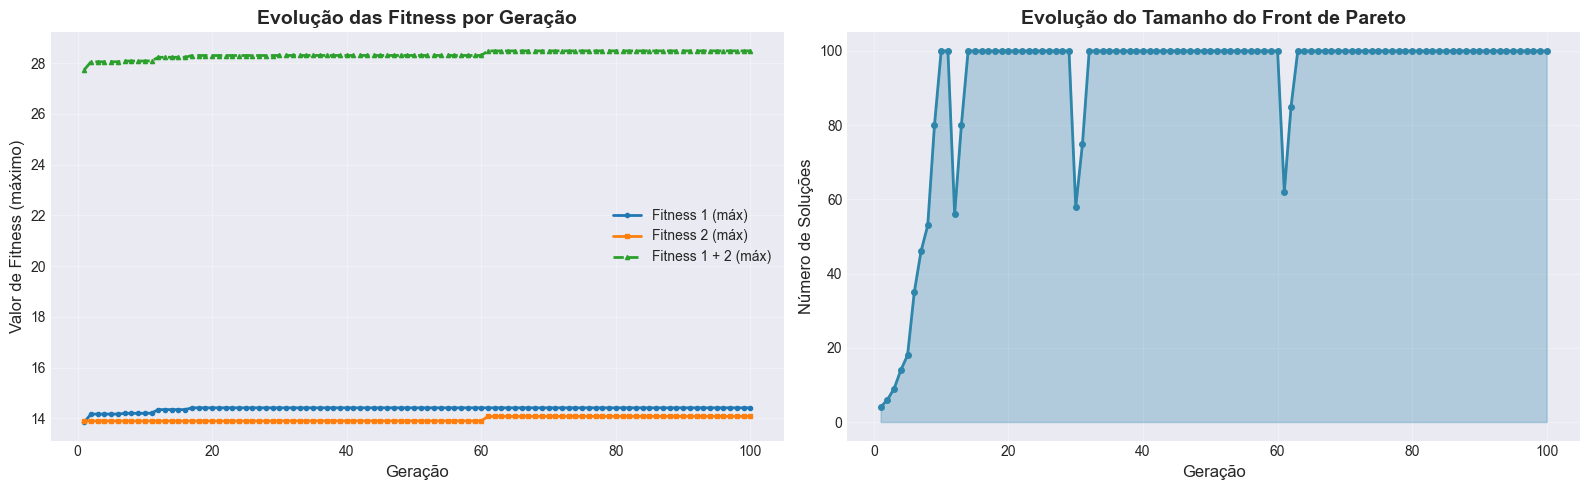


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [00:17<00:00,  5.81it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 4


In [17]:
df_pareto_my, _, _, _  = run_my_nsga2(config, df_predicted)
df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape2, save_history=True)

### Problema 2. Landscape Real

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 4,416 pontos.
Isso representa 0.4416% do espaço de busca.


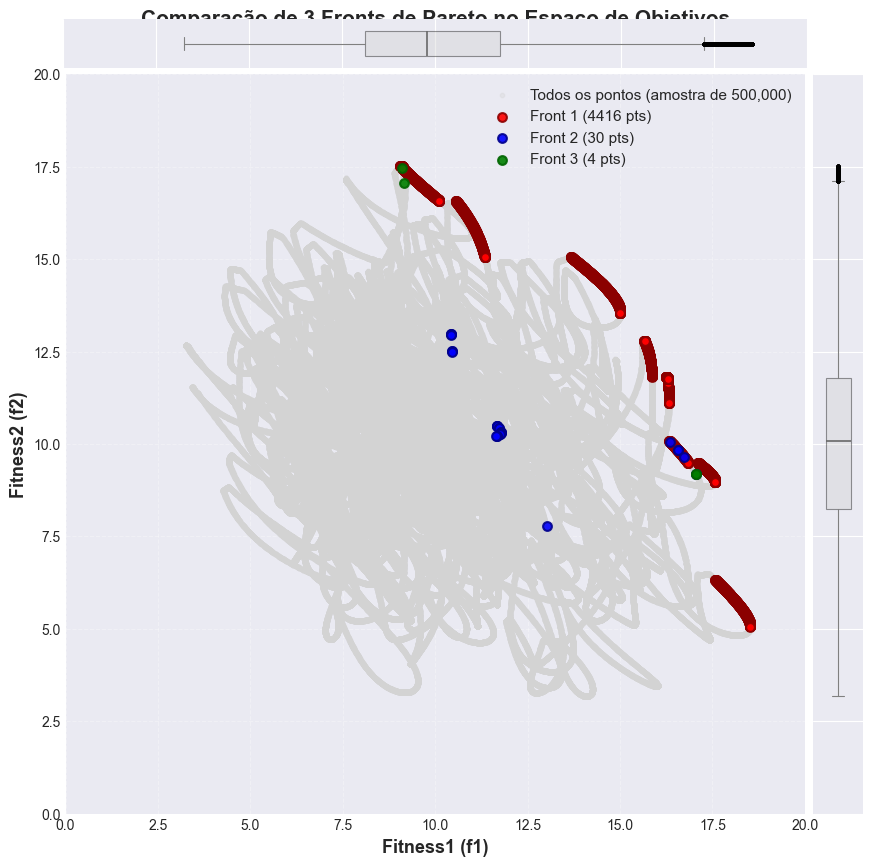

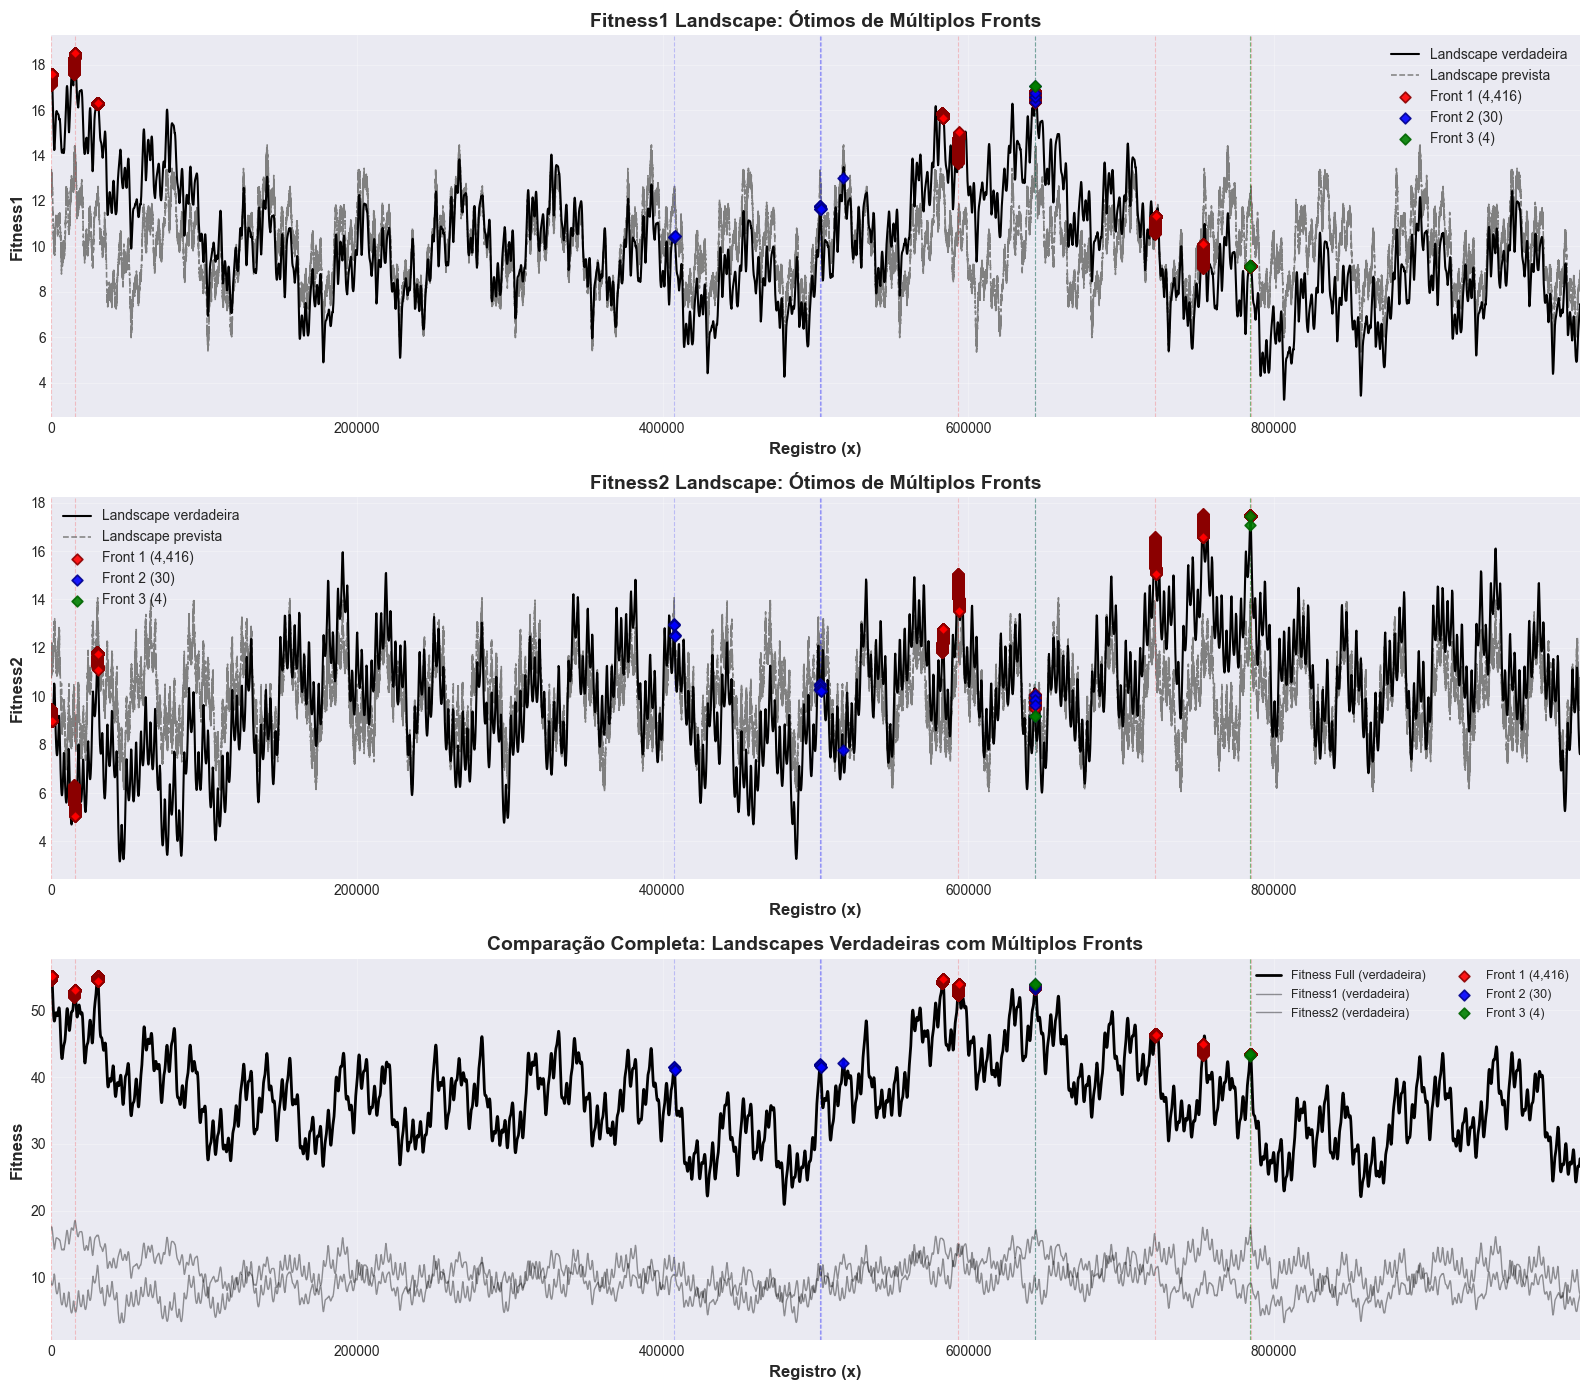

===================== gamma ua-sa-nsga2 =====================
🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.204515
   • Desvio Padrão:            0.106207
===================== gamma nsga2 =====================
🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        3.076214
   • Desvio Padrão:            1.691342


In [18]:
df_pareto_real = find_pareto_front(df)

df_pareto_real = df[df.registro.isin(df_pareto_real.registro.unique())]
df_pareto_my = df[df.registro.isin(df_pareto_my.registro.unique())]
df_pareto_ua_sa = df[df.registro.isin(df_pareto_ua_sa.registro.unique())]

# convergencia entre resultados
display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa])
display_fitness_landscape_with_paretos(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa])#, n_regioes=10)

print('===================== gamma ua-sa-nsga2 =====================')
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

print('===================== gamma nsga2 =====================')
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

In [19]:
# Gerar GIF com a evolução das populações
caminho_gif = gerar_gif_evolucao_nsga2(
    df_landscape=df2,  # Mesmo dataframe usado acima
    history=history,
    nome_arquivo='evolucao_ua_sa_nsga2_df2.gif',
    fps=5,  # Ajuste a velocidade conforme preferir
    output_dir='data'
)

print(f"GIF salvo em: {caminho_gif}")

Iniciando a geração de 101 frames...
Processado 10/101 frames...
Processado 20/101 frames...
Processado 30/101 frames...
Processado 40/101 frames...
Processado 50/101 frames...
Processado 60/101 frames...
Processado 70/101 frames...
Processado 80/101 frames...
Processado 90/101 frames...
Processado 100/101 frames...
Salvando arquivo 'evolucao_ua_sa_nsga2_df2.gif' no diretório 'data'...

✅ Sucesso! GIF gerado em:
/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/data/evolucao_ua_sa_nsga2_df2.gif
GIF salvo em: /Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/data/evolucao_ua_sa_nsga2_df2.gif


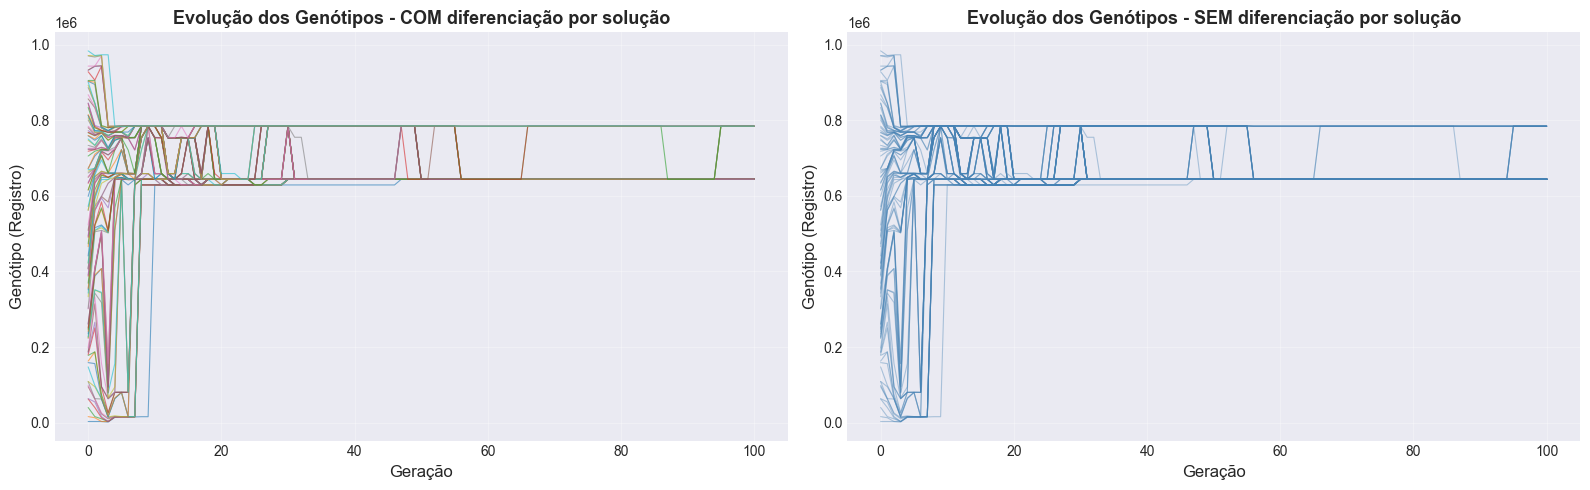


📊 Estatísticas do histórico:
   • Total de registros: 10,100
   • Gerações: 101
   • Soluções por geração: 100
   • Genótipos únicos visitados: 414


In [20]:
df_history = history_to_dataframe(history).drop(columns=['id_solucao'])
df_history = df_history.sort_values(by=['geracao','genotipo'])
df_history['id_solucao'] = df_history.groupby(['geracao']).cumcount() + 1
display_evolution_of_genotypes(df_history)

### Problema 2. Landscape Previsto

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 691 pontos.
Isso representa 0.0691% do espaço de busca.


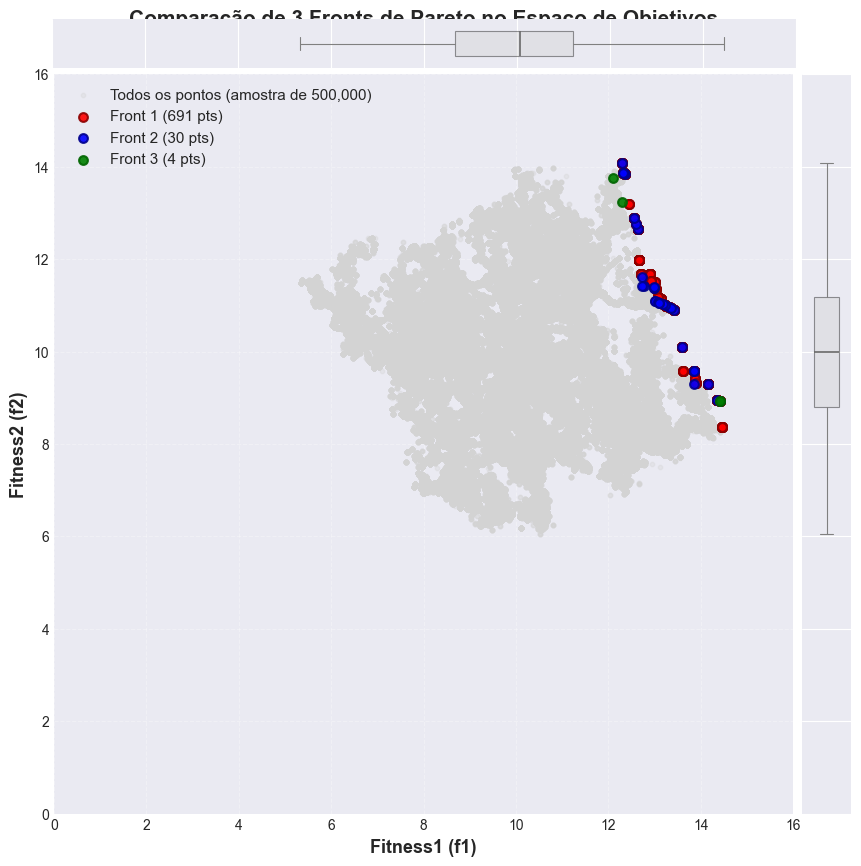

===================== gamma ua-sa-nsga2 =====================
🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.104326
   • Desvio Padrão:            0.109620
===================== gamma nsga2 =====================
🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.038183
   • Desvio Padrão:            0.056132


In [21]:
df_pareto_real = find_pareto_front(df_predicted)

df_pareto_real = df_predicted[df_predicted.registro.isin(df_pareto_real.registro.unique())]
df_pareto_my = df_predicted[df_predicted.registro.isin(df_pareto_my.registro.unique())]
df_pareto_ua_sa = df_predicted[df_predicted.registro.isin(df_pareto_ua_sa.registro.unique())]

# convergencia entre resultados
display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_ua_sa])

print('===================== gamma ua-sa-nsga2 =====================')
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_ua_sa)
print_gamma_metric(gamma_results)

print('===================== gamma nsga2 =====================')
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)